# Predicting House Prices with Linear Regression — Oasis Infobyte Data Analytics Internship (Level 2, Task 1)

**Author:** Ngninmeu Fondjo Marius Loic
**Track:** Data Analytics
**Dataset:** USA Housing dataset (5,000 records) — average area income, house age, number of rooms/bedrooms, and area population, with sale price as the target.

This notebook builds and evaluates an end-to-end linear regression model to predict house prices, per the OIBSIP Level 2 task checklist.

## 1. Data Loading & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('USA_Housing.csv')
print("Shape:", df.shape)
df.head()

Shape: (5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,97429.90,4.69,7.79,3.76,35772.42,4382322.21,East Lucas
1,75277.01,5.82,5.39,4.97,39268.32,4124859.88,East Lucas
2,78259.23,6.54,7.58,3.60,30076.50,4244434.60,East Lucas
3,73952.27,6.23,5.79,2.60,27049.09,3980398.25,Lake Christinaport
4,75521.96,5.18,7.06,3.84,30838.95,4048170.92,Lake Kathleen


In [2]:
df.info()
print("\nNull check:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB

Null check:
 Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


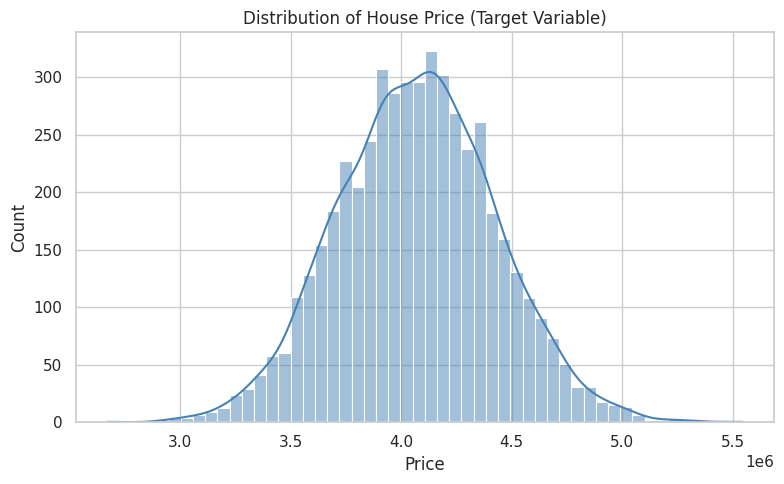

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True, color='steelblue')
plt.title('Distribution of House Price (Target Variable)')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=110)
plt.show()

**Observation:** No missing values. The target variable `Price` is roughly normally distributed, which is favourable for linear regression (no need for a log-transform, unlike many real-world, right-skewed housing datasets).

## 2. Feature Selection Discussion

The dataset provides 5 numerical predictors plus a categorical `Address` field. `Address` is a free-text, high-cardinality field (near-unique per row) that carries no generalisable signal for a linear model without heavy feature engineering (e.g. geocoding), so it is **dropped**. The 5 numerical features — Avg. Area Income, Avg. Area House Age, Avg. Area Number of Rooms, Avg. Area Number of Bedrooms, and Area Population — are retained as likely predictors: income and population reflect the economic strength of the area, while house age and room/bedroom counts reflect the physical characteristics of the property itself.

In [4]:
df_model = df.drop(columns=['Address'])
df_model.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,97429.90,4.69,7.79,3.76,35772.42,4382322.21
1,75277.01,5.82,5.39,4.97,39268.32,4124859.88
2,78259.23,6.54,7.58,3.60,30076.50,4244434.60
3,73952.27,6.23,5.79,2.60,27049.09,3980398.25
4,75521.96,5.18,7.06,3.84,30838.95,4048170.92


## 3. Missing Values & Encoding

In [5]:
# No missing values were found in step 1, and no remaining categorical columns need encoding
# after dropping Address - the feature set is already fully numerical.
print(df_model.dtypes)

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
dtype: object


## 4. Correlation Heatmap

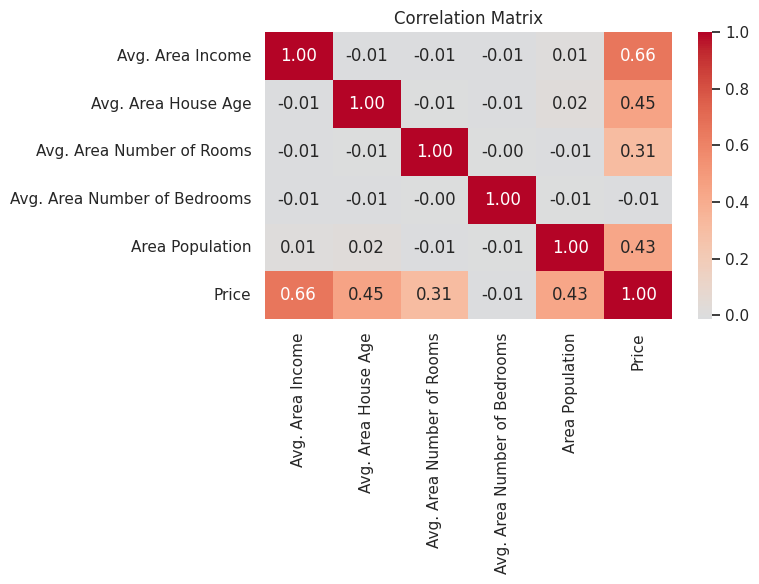

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df_model.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=110)
plt.show()

**Observation:** `Avg. Area Income` has the strongest correlation with `Price`, followed by `Avg. Area House Age` and `Area Population`. `Avg. Area Number of Bedrooms` shows almost no correlation with price, suggesting it may contribute little predictive power on its own.

## 5. Train/Test Split

In [7]:
X = df_model.drop(columns=['Price'])
y = df_model['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (4000, 5) | Test shape: (1000, 5)


## 6. Training the Linear Regression Model

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Model trained.")

Model trained.


## 7. Model Evaluation

In [9]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

MSE:  9,859,041,875.76
RMSE: 99,292.71
R2 Score: 0.9222


**Observation:** The model explains a large share of the variance in house prices (see R² above). RMSE gives the typical prediction error in the same units as price ($), which is more interpretable for a business stakeholder than MSE alone.

## 8. Actual vs. Predicted Prices

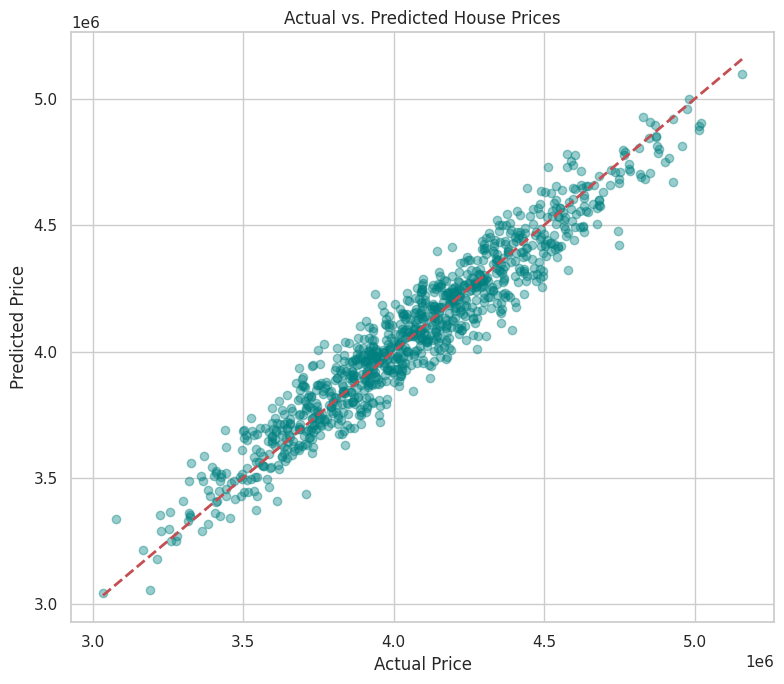

In [10]:
plt.figure(figsize=(8,7))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=110)
plt.show()

**Observation:** Predicted values cluster tightly around the diagonal reference line, indicating the model captures the overall price trend well, with no strong systematic bias toward over- or under-predicting at either end of the price range.

## 9. Residual Plot

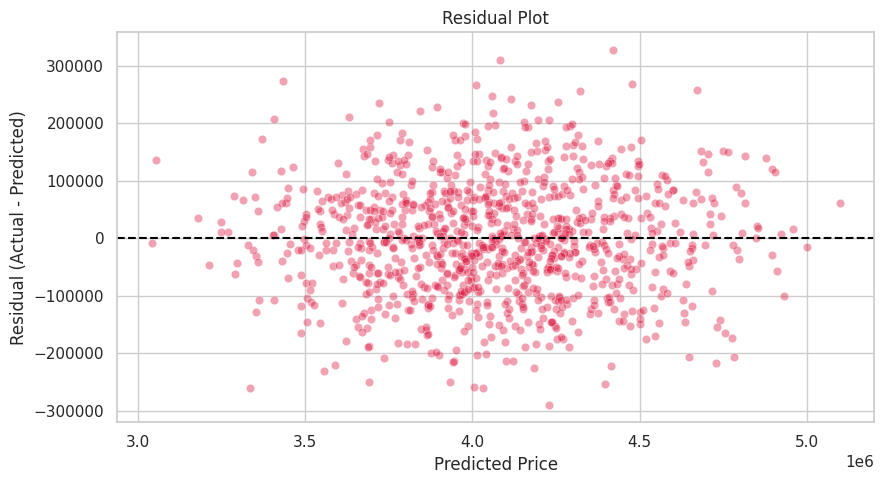

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(9,5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, color='crimson')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=110)
plt.show()

**Observation:** Residuals are scattered randomly around zero with no visible funnel shape or curve, suggesting the linear model's assumptions (homoscedasticity, linearity) are reasonably well satisfied for this dataset — no systematic pattern was missed.

## 10. Coefficient Analysis

/tmp/ipykernel_111/3205782930.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')


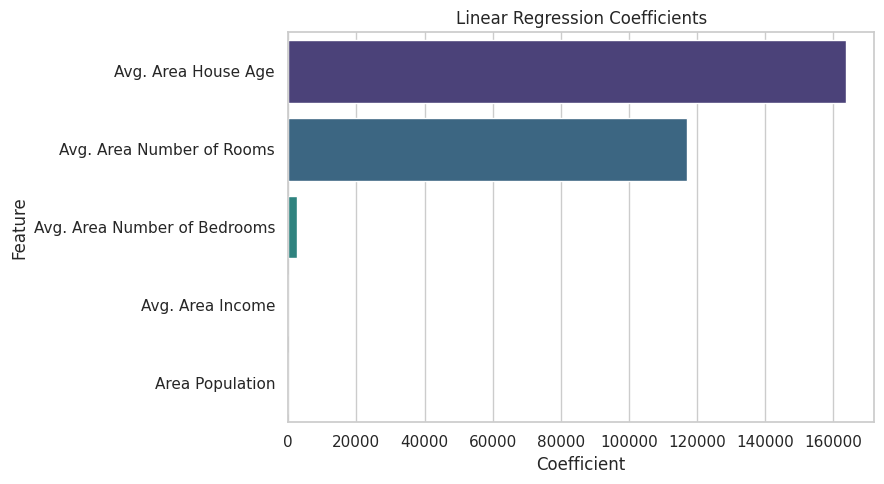

,Feature,Coefficient
1,Avg. Area House Age,163744.766835
2,Avg. Area Number of Rooms,116931.792146
3,Avg. Area Number of Bedrooms,2497.440327
0,Avg. Area Income,21.438171
4,Area Population,15.298983


In [12]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')
plt.title('Linear Regression Coefficients')
plt.tight_layout()
plt.savefig('coefficients.png', dpi=110)
plt.show()
coef_df

**Observation:** `Avg. Area House Age` and `Avg. Area Number of Rooms` have the largest positive impact on predicted price per unit increase, followed by income and population. `Avg. Area Number of Bedrooms` has a coefficient close to zero, confirming the weak correlation observed earlier — it contributes little once the other features are accounted for.

## 11. Bonus — Comparison with Ridge and Lasso Regression

In [13]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (alpha=1.0)', 'Lasso (alpha=1.0)'],
    'RMSE': [
        rmse,
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    'R2 Score': [
        r2,
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})
comparison

,Model,RMSE,R2 Score
0,Linear Regression,99292.708069,0.922190
1,Ridge (alpha=1.0),99289.624369,0.922195
2,Lasso (alpha=1.0),99292.598027,0.922190


**Observation:** Ridge and Lasso perform nearly identically to plain Linear Regression here — expected, since with only 5 well-behaved, weakly-collinear features, there is little overfitting for regularisation to correct. Regularisation would matter more with a larger, more collinear feature set (e.g. one-hot encoded location data).

---
*Prepared for the Oasis Infobyte Data Analytics Internship — Level 2, Task 1 (Predicting House Prices with Linear Regression).*